## Comparação: Classificação Humana vs Gemini 3.0 Flash

Este notebook compara os critérios de inclusão classificados manualmente (`articles.json`) com os scores gerados pelo modelo GEMINI (`result.json`), gerando um arquivo CSV consolidado. Este notebook também utiliza a os criterios reformulados para frases em afirmativo.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import json
import pandas as pd
import os


ARTICLES_PATH = "/home/jelson/Projetos/SE4AI-MLOps-Mapping/llm-sm-selection/data/articles.json"
RESULT_PATH   = '/home/jelson/Projetos/SE4AI-MLOps-Mapping/llm-sm-selection/results/gemini-3-flash-afirmation/result.json'
OUTPUT_CSV    = 'reports/comparacao-gemini-3-flash-afirmation.csv'

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Pré-processamento do `articles.json`

Extração das colunas base e derivação dos critérios de inclusão humanos (CI1, CI2, CI3).

> **Lógica:** O campo `Inclusão` indica até qual critério o artigo foi incluído.
> Caso o campo `Inclusão` seja nulo, todos os CIs são 0.

In [33]:
with open(ARTICLES_PATH, 'r', encoding='utf-8') as f:
    articles = json.load(f)[:100]

with open(RESULT_PATH, 'r', encoding='utf-8') as f:
    results = json.load(f)

print(f'articles.json: {len(articles)} registros')
print(f'result.json:   {len(results)} registros')

articles.json: 100 registros
result.json:   100 registros


In [34]:
CRITERIOS_ORDEM = ['CI1', 'CI2', 'CI3']

def extrair_cis_humanos(inclusao_val):
    """Retorna dict com CI1, CI2, CI3 (0 ou 1) baseado no campo Inclusão."""
    result = {'CI1': False, 'CI2': False, 'CI3': False}
    if not inclusao_val:
        return result
    inclusao_val = str(inclusao_val).strip().upper()
    for ci in CRITERIOS_ORDEM:
        if ci in inclusao_val:
            result[ci] = True
    return result

rows_articles = []
for art in articles:
    cis = extrair_cis_humanos(art.get('Inclusão'))
    rows_articles.append({
        'DOI':    art.get('DOI'),
        'ISBNs':  art.get('ISBNs'),
        'ISSN':   art.get('ISSN'),
        'Título': art.get('Título'),
        'Autor':  art.get('Autor'),
        'Abstract': art.get('Abstract'),
        'Ano':    art.get('Ano'),
        'CI1':    cis['CI1'],
        'CI2':    cis['CI2'],
        'CI3':    cis['CI3'],
    })

df_articles = pd.DataFrame(rows_articles)
df_articles['DOI'] = df_articles['DOI'].str.strip()
print(f'Shape: {df_articles.shape}')
df_articles.head()

Shape: (100, 10)


,DOI,ISBNs,ISSN,Título,Autor,Abstract,Ano,CI1,CI2,CI3
0,10.1109/CAIN66642.2025.00045,979-8-3315-0219-5,NaN,A Holistic Framework for Evolving AI-Based Sys...,M. Veracx,Building easily modifiable software systems is...,2025,True,False,False
1,10.1109/CAIN58948.2023.00035,979-8-3503-0113-7,NaN,Design Patterns for AI-based Systems: A Multiv...,L. Heiland; M. Hauser; J. Bogner,Systems with artificial intelligence component...,2023,True,True,True
2,10.1109/WAIN52551.2021.00022,978-1-6654-4470-5,NaN,Data acquisition and the implications of machi...,M. Unger,"The abundance of healthcare data, with the col...",2021,False,False,False
3,10.1109/FIE56618.2022.9962523,978-1-6654-6244-0,2377-634X,Crafting an Undergraduate Course at the Inters...,S. Chenoweth; P. K. Linos,This is a work-in-progress innovative practice...,2022,False,False,False
4,10.1109/ICIMIA67127.2025.11200580,979-8-3315-5386-9,NaN,UML-based Modeling of Quantum Machine Learning...,K. Sharma; V. M; K. K; S. G,Quantum Machine learning (QML) is the combinat...,2025,False,False,False


## 2. Pré-processamento do `result.json` (GEMINI)

Extração dos scores IC1, IC2, IC3 gerados pelo modelo.

In [35]:
def extrair_score(inclusion_results, criterion):
    """Busca o score de um critério específico na lista inclusion_results."""
    for item in inclusion_results:
        if item.get('criterion', '').upper() == criterion.upper():
            return item.get('score')
    return None

rows_gemini = []
for res in results:
    meta = res.get('article_metadata', {})
    inc  = res.get('inclusion_results', [])
    doi  = meta.get('DOI', '')
    rows_gemini.append({
        'DOI':         doi.strip() if doi else doi,
        'Título':      meta['title'],
        'Autor':       meta['author'],
        'Ano':         meta['year'],
        'CI1_GEMINI':  extrair_score(inc, 'CI1'),
        'CI2_GEMINI':  extrair_score(inc, 'CI2'),
        'CI3_GEMINI':  extrair_score(inc, 'CI3'),
    })

df_gemini = pd.DataFrame(rows_gemini)
mean_cols = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
print(f'Shape: {df_gemini.shape}')
df_gemini.head()

Shape: (100, 7)


,DOI,Título,Autor,Ano,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI
0,10.1109/CAIN66642.2025.00045,A Holistic Framework for Evolving AI-Based Sys...,M. Veracx,2025,7.0,6.0,5.0
1,10.1109/CAIN58948.2023.00035,Design Patterns for AI-based Systems: A Multiv...,L. Heiland; M. Hauser; J. Bogner,2023,7.0,7.0,5.0
2,10.1109/WAIN52551.2021.00022,Data acquisition and the implications of machi...,M. Unger,2021,7.0,5.0,6.0
3,10.1109/FIE56618.2022.9962523,Crafting an Undergraduate Course at the Inters...,S. Chenoweth; P. K. Linos,2022,7.0,NaN,6.0
4,10.1109/ICIMIA67127.2025.11200580,UML-based Modeling of Quantum Machine Learning...,K. Sharma; V. M; K. K; S. G,2025,7.0,6.0,5.0


## 3. Merge dos DataFrames

In [36]:
df_merged = df_articles.merge(df_gemini, on=['Título', 'Autor', 'Ano'], how='left')

# Selecionar e ordenar colunas finais
cols_final = ['ISBNs', 'ISSN', 'Título', 'Abstract', 'Autor', 'Ano',
              'CI1', 'CI2', 'CI3',
              'CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df_final = df_merged[cols_final]

print(f'Total de artigos no CSV final: {len(df_final)}')
print(f'Artigos sem match GEMINI: {df_final["CI1_GEMINI"].isna().sum()}')
df_final.to_csv(OUTPUT_CSV, index=False)
df_final.head(10)

Total de artigos no CSV final: 100
Artigos sem match GEMINI: 4


,ISBNs,ISSN,Título,Abstract,Autor,Ano,CI1,CI2,CI3,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI
0,979-8-3315-0219-5,NaN,A Holistic Framework for Evolving AI-Based Sys...,Building easily modifiable software systems is...,M. Veracx,2025,True,False,False,7.0,6.0,5.0
1,979-8-3503-0113-7,NaN,Design Patterns for AI-based Systems: A Multiv...,Systems with artificial intelligence component...,L. Heiland; M. Hauser; J. Bogner,2023,True,True,True,7.0,7.0,5.0
2,978-1-6654-4470-5,NaN,Data acquisition and the implications of machi...,"The abundance of healthcare data, with the col...",M. Unger,2021,False,False,False,7.0,5.0,6.0
3,978-1-6654-6244-0,2377-634X,Crafting an Undergraduate Course at the Inters...,This is a work-in-progress innovative practice...,S. Chenoweth; P. K. Linos,2022,False,False,False,7.0,NaN,6.0
4,979-8-3315-5386-9,NaN,UML-based Modeling of Quantum Machine Learning...,Quantum Machine learning (QML) is the combinat...,K. Sharma; V. M; K. K; S. G,2025,False,False,False,7.0,6.0,5.0
5,978-1-6654-1405-0,NaN,Characterizing Technical Debt and Antipatterns...,Background: With the rising popularity of Arti...,J. Bogner; R. Verdecchia; I. Gerostathopoulos,2021,False,False,False,7.0,7.0,6.0
6,979-8-4007-0591-5,NaN,Continuous Quality Assurance and ML Pipelines ...,"More than ever, Machine Learning (ML) as a sub...",M. Wagner,2024,True,False,True,7.0,5.0,6.0
7,978-1-6654-4470-5,NaN,Lessons Learned from Educating AI Engineers,Over the past three years we have built a prac...,P. Heck; G. Schouten,2021,True,True,False,6.0,5.0,5.0
8,978-1-6654-4470-5,NaN,Who Needs MLOps: What Data Scientists Seek to ...,Following continuous software engineering prac...,S. Mäkinen; H. Skogström; E. Laaksonen; T. Mik...,2021,True,False,True,7.0,5.0,6.0
9,978-1-7281-8047-2,NaN,Does System Based on Artificial Intelligence N...,Software engineering is the most important sta...,I. W. Syahputri; R. Ferdiana; S. S. Kusumawardani,2020,True,False,True,7.0,6.0,5.0


## 4. Análise Exploratória Rápida

In [37]:
threshold = 6

for i in range(1, 4):
    real_col = f'CI{i}'
    gemini_col = f'CI{i}_GEMINI'
    result_col = f'RESULT_CI{i}'
    
    df_final[result_col] = (df_final[real_col] == (df_final[gemini_col] >= threshold)).map({True: 'C', False: 'E'})

df_final.head(10)

,ISBNs,ISSN,Título,Abstract,Autor,Ano,CI1,CI2,CI3,CI1_GEMINI,CI2_GEMINI,CI3_GEMINI,RESULT_CI1,RESULT_CI2,RESULT_CI3
0,979-8-3315-0219-5,NaN,A Holistic Framework for Evolving AI-Based Sys...,Building easily modifiable software systems is...,M. Veracx,2025,True,False,False,7.0,6.0,5.0,C,E,C
1,979-8-3503-0113-7,NaN,Design Patterns for AI-based Systems: A Multiv...,Systems with artificial intelligence component...,L. Heiland; M. Hauser; J. Bogner,2023,True,True,True,7.0,7.0,5.0,C,C,E
2,978-1-6654-4470-5,NaN,Data acquisition and the implications of machi...,"The abundance of healthcare data, with the col...",M. Unger,2021,False,False,False,7.0,5.0,6.0,E,C,E
3,978-1-6654-6244-0,2377-634X,Crafting an Undergraduate Course at the Inters...,This is a work-in-progress innovative practice...,S. Chenoweth; P. K. Linos,2022,False,False,False,7.0,NaN,6.0,E,C,E
4,979-8-3315-5386-9,NaN,UML-based Modeling of Quantum Machine Learning...,Quantum Machine learning (QML) is the combinat...,K. Sharma; V. M; K. K; S. G,2025,False,False,False,7.0,6.0,5.0,E,E,C
5,978-1-6654-1405-0,NaN,Characterizing Technical Debt and Antipatterns...,Background: With the rising popularity of Arti...,J. Bogner; R. Verdecchia; I. Gerostathopoulos,2021,False,False,False,7.0,7.0,6.0,E,E,E
6,979-8-4007-0591-5,NaN,Continuous Quality Assurance and ML Pipelines ...,"More than ever, Machine Learning (ML) as a sub...",M. Wagner,2024,True,False,True,7.0,5.0,6.0,C,C,C
7,978-1-6654-4470-5,NaN,Lessons Learned from Educating AI Engineers,Over the past three years we have built a prac...,P. Heck; G. Schouten,2021,True,True,False,6.0,5.0,5.0,C,E,C
8,978-1-6654-4470-5,NaN,Who Needs MLOps: What Data Scientists Seek to ...,Following continuous software engineering prac...,S. Mäkinen; H. Skogström; E. Laaksonen; T. Mik...,2021,True,False,True,7.0,5.0,6.0,C,C,C
9,978-1-7281-8047-2,NaN,Does System Based on Artificial Intelligence N...,Software engineering is the most important sta...,I. W. Syahputri; R. Ferdiana; S. S. Kusumawardani,2020,True,False,True,7.0,6.0,5.0,C,E,E


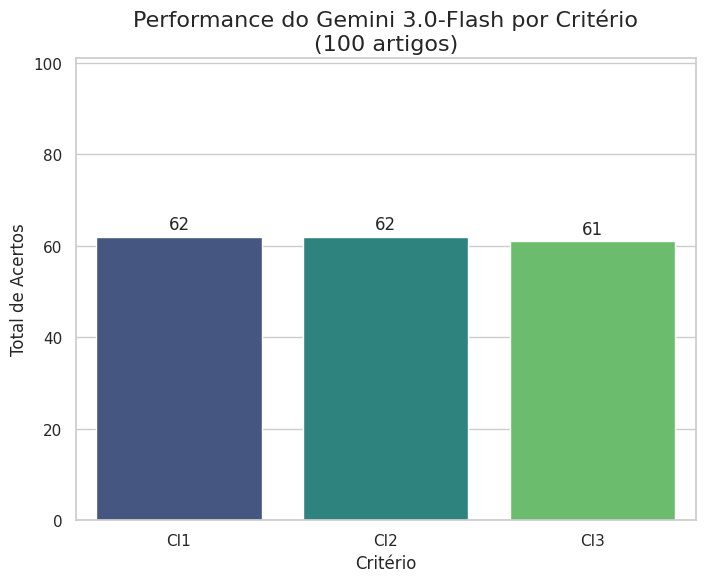

In [38]:
resultados = []
for i in range(1, 4):
    total_acertos = (df_final[f'RESULT_CI{i}'] == 'C').sum()
    resultados.append({'Critério': f'CI{i}', 'Acertos': total_acertos})

df_plot = pd.DataFrame(resultados)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

grafico = sns.barplot(
    x='Critério', 
    y='Acertos', 
    data=df_plot, 
    palette='viridis',
    hue='Critério',
    legend=False 
)

for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Performance do Gemini 3.0-Flash por Critério\n(100 artigos)', fontsize=16)
plt.ylabel('Total de Acertos')
plt.ylim(0, len(df_final) + 1)
plt.show()

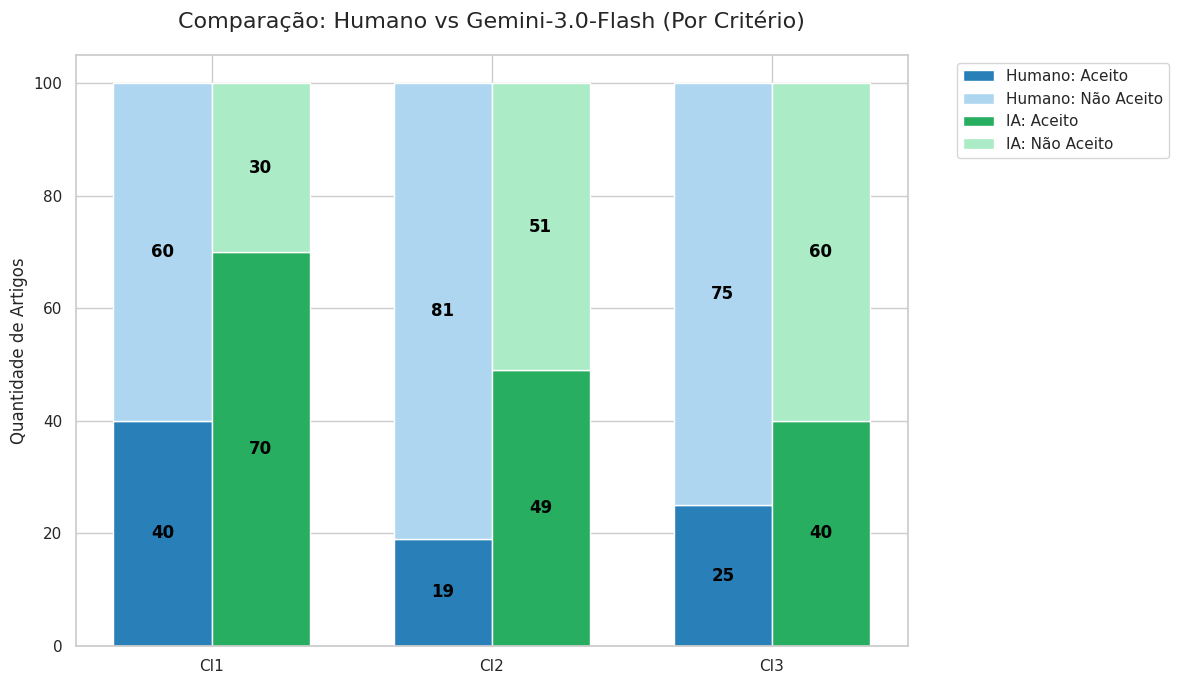

In [39]:
dados = []
threshold = 6

for i in range(1, 4):
    h_aceitos = df_final[f'CI{i}'].sum()
    h_nao_aceitos = len(df_final) - h_aceitos
    
    ia_aceitos = (df_final[f'CI{i}_GEMINI'] >= threshold).sum()
    ia_nao_aceitos = len(df_final) - ia_aceitos
    
    dados.append({
        'Critério': f'CI{i}',
        'Humano_Aceito': h_aceitos,
        'Humano_Não_Aceito': h_nao_aceitos,
        'IA_Aceito': ia_aceitos,
        'IA_Não_Aceito': ia_nao_aceitos
    })

df_comp = pd.DataFrame(dados).set_index('Critério')

fig, ax = plt.subplots(figsize=(12, 7))

width = 0.35
x = range(len(df_comp))

ax.bar([i - width/2 for i in x], df_comp['Humano_Aceito'], width, label='Humano: Aceito', color='#2980b9')
ax.bar([i - width/2 for i in x], df_comp['Humano_Não_Aceito'], width, bottom=df_comp['Humano_Aceito'], 
       label='Humano: Não Aceito', color='#aed6f1')

ax.bar([i + width/2 for i in x], df_comp['IA_Aceito'], width, label='IA: Aceito', color='#27ae60')
ax.bar([i + width/2 for i in x], df_comp['IA_Não_Aceito'], width, bottom=df_comp['IA_Aceito'], 
       label='IA: Não Aceito', color='#abebc6')

ax.set_title('Comparação: Humano vs Gemini-3.0-Flash (Por Critério)', fontsize=16, pad=20)
ax.set_ylabel('Quantidade de Artigos')
ax.set_xticks(x)
ax.set_xticklabels(df_comp.index)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for i, rect in enumerate(ax.patches):
    height = rect.get_height()
    if height > 0:
        ax.text(rect.get_x() + rect.get_width()/2., rect.get_y() + height/2.,
                f'{int(height)}', ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

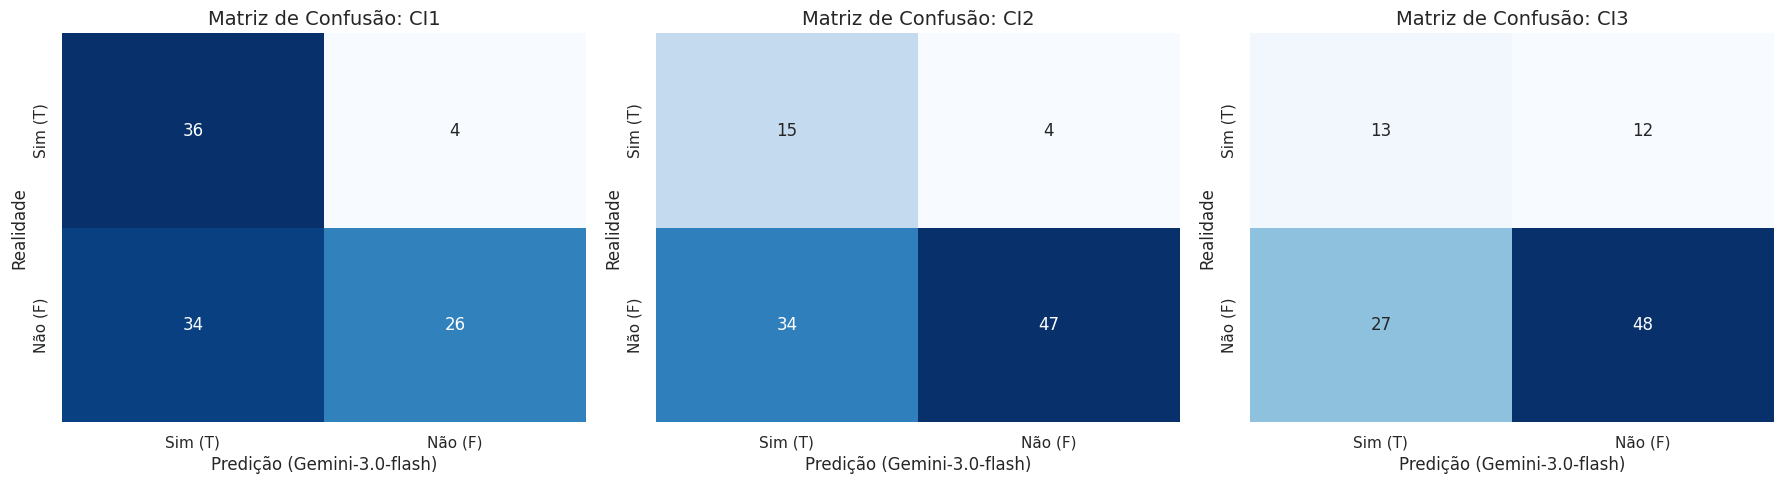

In [40]:
threshold = 6
criterios = ['CI1', 'CI2', 'CI3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, crit in enumerate(criterios):
    y_true = df_final[crit]
    y_pred = df_final[f'{crit}_GEMINI'] >= threshold
    cm = confusion_matrix(y_true, y_pred, labels=[True, False])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Sim (T)', 'Não (F)'],
        yticklabels=['Sim (T)', 'Não (F)'],
        cbar=False 
    )
    
    axes[i].set_title(f'Matriz de Confusão: {crit}', fontsize=14)
    axes[i].set_xlabel('Predição (Gemini-3.0-flash)')
    axes[i].set_ylabel('Realidade')

plt.tight_layout()
plt.show()

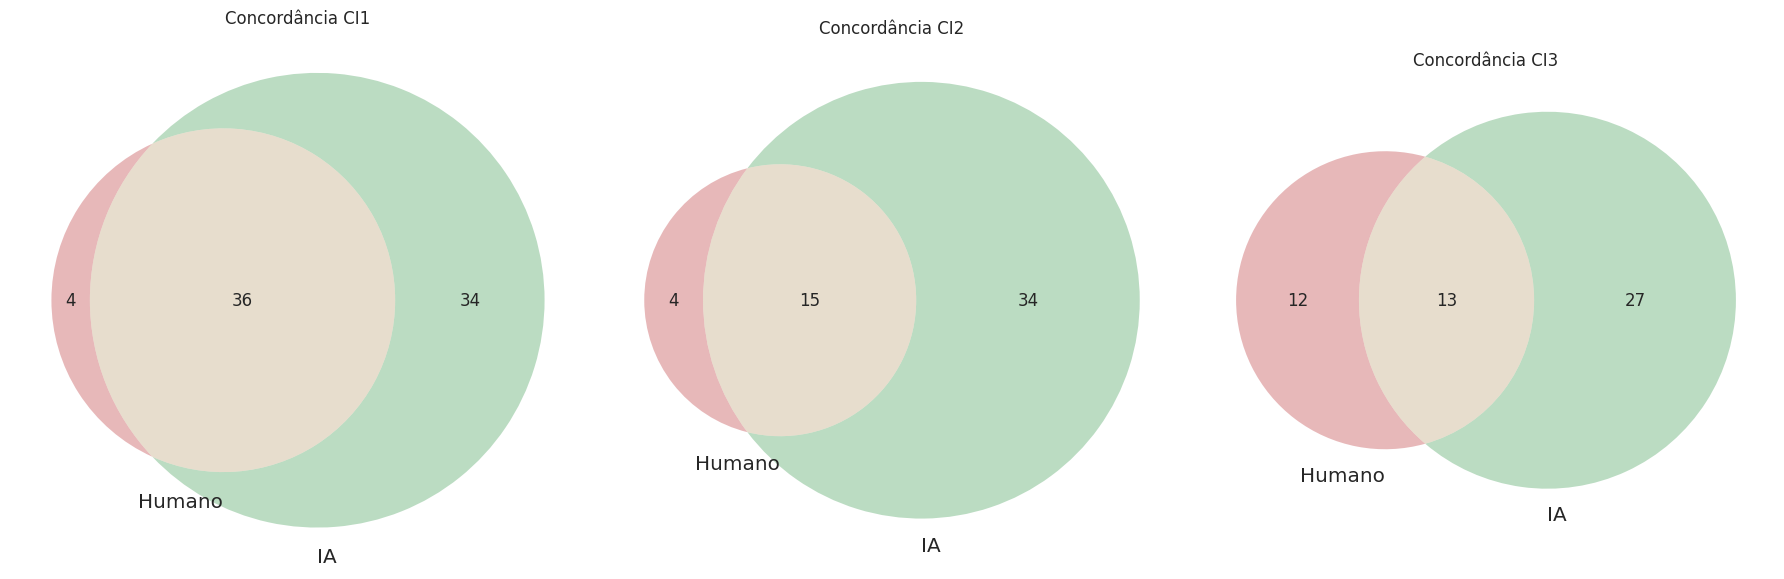

In [41]:
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(1, 4):
    real = df_final[f'CI{i}']
    pred = df_final[f'CI{i}_GEMINI'] >= 6
    
    # Cálculos para o Venn
    so_humano = ((real == True) & (pred == False)).sum()
    so_ia = ((real == False) & (pred == True)).sum()
    ambos = ((real == True) & (pred == True)).sum()
    
    venn2(subsets=(so_humano, so_ia, ambos), 
          set_labels=('Humano', 'IA'), 
          ax=axes[i-1])
    axes[i-1].set_title(f"Concordância CI{i}")

plt.tight_layout()
plt.show()

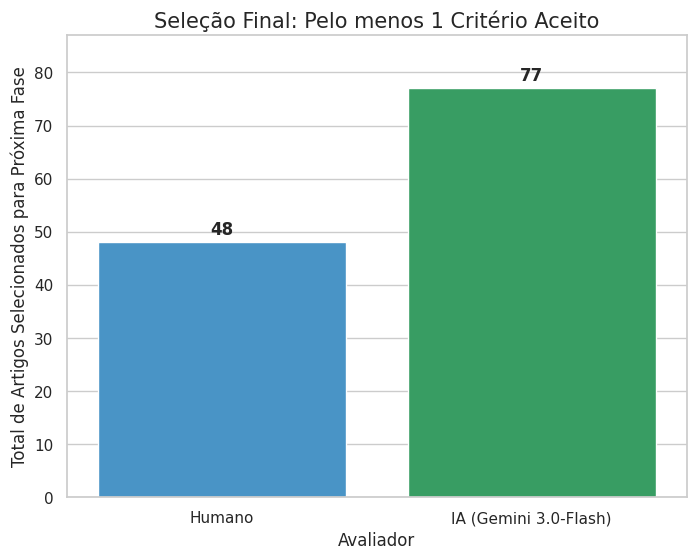

In [42]:
threshold = 6
df_final['INCLUSAO_HUMANO'] = df_final[['CI1', 'CI2', 'CI3']].any(axis=1)
cols_gemini = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df_final['INCLUSAO_IA'] = (df_final[cols_gemini] >= threshold).any(axis=1)

total_humano = df_final['INCLUSAO_HUMANO'].sum()
total_ia = df_final['INCLUSAO_IA'].sum()

df_resumo_final = pd.DataFrame({
    'Avaliador': ['Humano', 'IA (Gemini 3.0-Flash)'],
    'Artigos Incluídos': [total_humano, total_ia]
})

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 6))

grafico = sns.barplot(
    x='Avaliador', 
    y='Artigos Incluídos', 
    data=df_resumo_final, 
    hue='Avaliador', 
    palette=['#3498db', '#27ae60'],
    legend=False
)

for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.title('Seleção Final: Pelo menos 1 Critério Aceito', fontsize=15)
plt.ylabel('Total de Artigos Selecionados para Próxima Fase')
plt.ylim(0, max(total_humano, total_ia) + 10)
plt.show()

--- Totais de Seleção Final ---
Apenas Humano: 4
Apenas IA: 33
Ambos (Interseção): 44
------------------------------


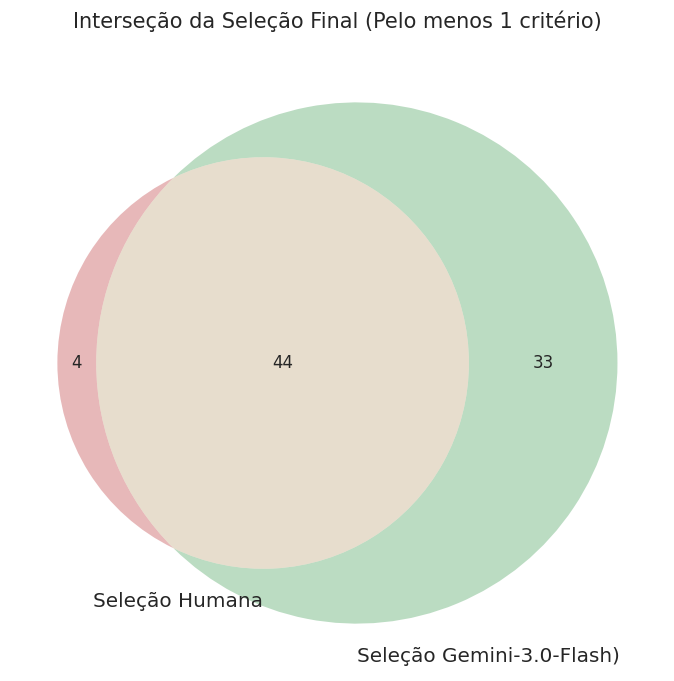

In [43]:
threshold = 6
df = df_final.copy()

df['INCLUSAO_HUMANO'] = df[['CI1', 'CI2', 'CI3']].any(axis=1)
cols_gemini = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
df['INCLUSAO_IA'] = (df[cols_gemini] >= threshold).any(axis=1)
so_humano = ((df['INCLUSAO_HUMANO'] == True) & (df['INCLUSAO_IA'] == False)).sum()
so_ia = ((df['INCLUSAO_HUMANO'] == False) & (df['INCLUSAO_IA'] == True)).sum()
ambos = ((df['INCLUSAO_HUMANO'] == True) & (df['INCLUSAO_IA'] == True)).sum()

print(f"--- Totais de Seleção Final ---")
print(f"Apenas Humano: {so_humano}")
print(f"Apenas IA: {so_ia}")
print(f"Ambos (Interseção): {ambos}")
print("-" * 30)

plt.figure(figsize=(10, 8))

v = venn2(subsets=(so_humano, so_ia, ambos), 
          set_labels=('Seleção Humana', 'Seleção Gemini-3.0-Flash)'))

plt.title("Interseção da Seleção Final (Pelo menos 1 critério)", fontsize=15, pad=20)

plt.show()

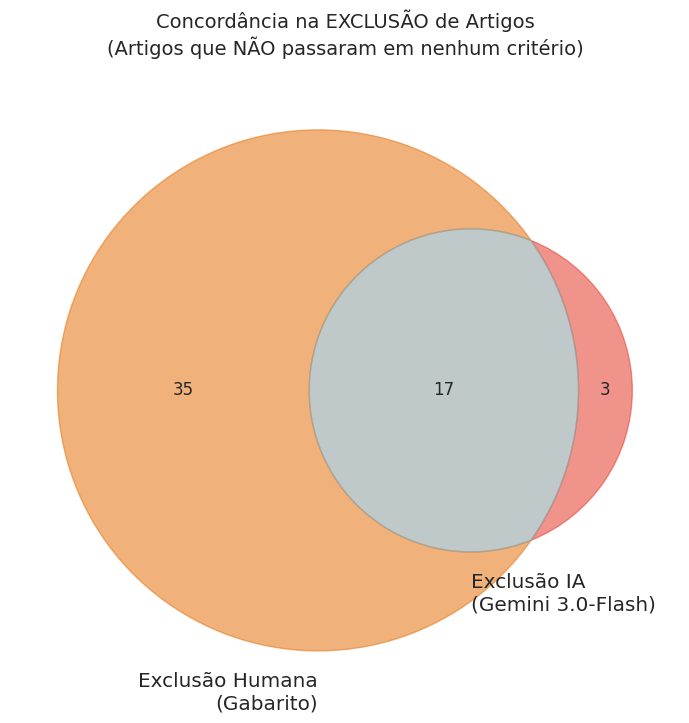

In [44]:
excluidos_humano = df_final[['CI1', 'CI2', 'CI3']].sum(axis=1) == 0
cols_gemini = ['CI1_GEMINI', 'CI2_GEMINI', 'CI3_GEMINI']
excluidos_ia = (df_final[cols_gemini] < threshold).all(axis=1)
so_humano_exc = ((excluidos_humano == True) & (excluidos_ia == False)).sum()
so_ia_exc = ((excluidos_humano == False) & (excluidos_ia == True)).sum()
ambos_exc = ((excluidos_humano == True) & (excluidos_ia == True)).sum()

plt.figure(figsize=(10, 8))
v_exc = venn2(subsets=(so_humano_exc, so_ia_exc, ambos_exc), 
              set_labels=('Exclusão Humana\n(Gabarito)', 'Exclusão IA\n(Gemini 3.0-Flash)'))

# Estilização Segura para tons de Vermelho/Laranja (Cores de Exclusão)
cores_exc = {'10': '#e67e22', '01': '#e74c3c', '11': '#95a5a6'} # Laranja, Vermelho, Cinza

for area_id, cor in cores_exc.items():
    patch = v_exc.get_patch_by_id(area_id)
    if patch:
        patch.set_color(cor)
        patch.set_alpha(0.6)

plt.title("Concordância na EXCLUSÃO de Artigos\n(Artigos que NÃO passaram em nenhum critério)", fontsize=14, pad=20)
plt.show()